In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 5. Feature Dictionary 

#### A. URL / Lexical Features

| Feature             | Meaning                                                                                       |
| ------------------- | --------------------------------------------------------------------------------------------- |
| `url`               | The complete website URL                                                                      |
| `entropy`           | A measure of how unpredictable/random the characters in the URL are                           |
| `url_length`        | Total length of the URL                                                                       |
| `num_www`           | Number of occurrences of `www`                                                                |
| `ratio_digits_url`  | Proportion of characters in the URL that are digits                                           |
| `num_subdomains`    | Number of subdomains                                                                          |
| `length_hostname`   | Length of the hostname                                                                        |
| `random_domain`     | Indicator related to whether the domain appears randomly generated                            |
| `num_dots`          | Number of dots in the URL                                                                     |
| `num_hyphens`       | Number of hyphens in the URL                                                                  |
| `ratio_digits_host` | Proportion of hostname characters that are digits                                             |
| `prefix_suffix`     | Indicator related to the presence of a prefix/suffix separator such as a hyphen in the domain |
| `num_question_mark` | Number of `?` characters in the URL                                                           |
| `num_eq`            | Number of `=` characters in the URL                                                           |


#### B. Domain / Network Features

| Feature            | Meaning                                                  |
| ------------------ | -------------------------------------------------------- |
| `domain_age`       | Age of the domain                                        |
| `dns_resolvable`   | Indicates whether the domain can be resolved through DNS |
| `num_ips`          | Number of IP addresses associated with the domain        |
| `ttl`              | DNS Time To Live value                                   |
| `num_name_servers` | Number of name servers associated with the domain        |


#### C. Target

| Feature | Meaning                                  |
| ------- | ---------------------------------------- |
| `label` | Target class: `phishing` or `legitimate` |


In [6]:
df = pd.read_excel(
    'Phishing dataset/Phishing dataset/url/merged_features_final.xlsx'
)

df.to_csv(
    'Phishing_dataset.csv',
    index=False
)
df = pd.read_csv('Phishing_dataset.csv')

In [7]:
df.head(11)

,url,entropy,url_length,num_www,ratio_digits_url,num_subdomains,length_hostname,random_domain,num_dots,num_hyphens,ratio_digits_host,prefix_suffix,num_question_mark,num_eq,domain_age,dns_resolvable,num_ips,ttl,num_name_servers,label
0,https://manua.ls,3.500000,16,0,0.000000,0,8,0,1,0,0.0,0,0,0,-1.0,1.0,1.0,3600.0,4.0,legitimate
1,https://t.co/r77VHQx9lP,4.023137,23,0,0.130435,0,4,1,1,0,0.0,0,0,0,5745.0,1.0,1.0,300.0,8.0,phishing
2,https://sites.google.com/view/attyahoo-plus-la...,4.145908,58,0,0.000000,1,16,0,2,3,0.0,0,0,0,10351.0,1.0,6.0,300.0,4.0,phishing
3,https://bit.ly/48c5385,3.845351,22,0,0.272727,0,6,0,1,0,0.0,0,0,0,6453.0,1.0,2.0,300.0,8.0,phishing
4,https://strato.de,3.381580,17,0,0.000000,0,9,0,1,0,0.0,0,0,0,-1.0,1.0,1.0,3600.0,4.0,legitimate
5,https://techmeme.com,3.308695,20,0,0.000000,0,12,0,1,0,0.0,0,0,0,7205.0,1.0,1.0,900.0,2.0,legitimate
6,https://mahabhumi.gov.in,3.886842,24,0,0.000000,0,16,0,2,0,0.0,0,0,0,2961.0,1.0,1.0,600.0,6.0,legitimate
7,https://goldenfrog.com,3.970573,22,0,0.000000,0,14,0,1,0,0.0,0,0,0,10881.0,1.0,1.0,300.0,4.0,legitimate
8,https://myproductglobalsource.weebly.com/,4.192322,41,0,0.000000,1,32,0,2,0,0.0,0,0,0,7234.0,1.0,2.0,900.0,4.0,phishing
9,https://www.dropbox.com/scl/fi/av83rq75mbe8otu...,5.251272,100,1,0.180000,1,15,0,2,1,0.0,0,1,2,11161.0,1.0,1.0,60.0,4.0,phishing


In [8]:
df.shape

(60000, 20)

In [10]:
df.shape[1]

20

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   url                60000 non-null  object 
 1   entropy            60000 non-null  float64
 2   url_length         60000 non-null  int64  
 3   num_www            60000 non-null  int64  
 4   ratio_digits_url   60000 non-null  float64
 5   num_subdomains     60000 non-null  int64  
 6   length_hostname    60000 non-null  int64  
 7   random_domain      60000 non-null  int64  
 8   num_dots           60000 non-null  int64  
 9   num_hyphens        60000 non-null  int64  
 10  ratio_digits_host  60000 non-null  float64
 11  prefix_suffix      60000 non-null  int64  
 12  num_question_mark  60000 non-null  int64  
 13  num_eq             60000 non-null  int64  
 14  domain_age         59998 non-null  float64
 15  dns_resolvable     59998 non-null  float64
 16  num_ips            599

In [12]:
df.describe()

,entropy,url_length,num_www,ratio_digits_url,num_subdomains,length_hostname,random_domain,num_dots,num_hyphens,ratio_digits_host,prefix_suffix,num_question_mark,num_eq,domain_age,dns_resolvable,num_ips,ttl,num_name_servers
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,59998.000000,59998.000000,59998.000000,59998.000000,59998.000000
mean,4.072082,44.119367,0.097650,0.045301,0.481783,16.661200,0.148483,1.669483,0.473500,0.033072,0.089133,0.111767,0.316533,4612.265242,0.930431,2.157289,2021.353812,3.264725
std,0.563020,117.729571,0.298746,0.084466,0.576923,10.369705,0.355581,0.975325,1.102173,0.103449,0.284938,0.337802,1.232206,4278.130614,0.254421,1.652185,5197.928535,1.743701
min,2.353338,12.000000,0.000000,0.000000,0.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,-1.000000,0.000000
25%,3.719295,21.000000,0.000000,0.000000,0.000000,10.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,1.000000,60.000000,2.000000
50%,3.936260,24.000000,0.000000,0.000000,0.000000,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4543.000000,1.000000,2.000000,300.000000,4.000000
75%,4.222208,41.000000,0.000000,0.067797,1.000000,20.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,8601.000000,1.000000,3.000000,600.000000,4.000000
max,6.032729,25523.000000,3.000000,0.826087,7.000000,100.000000,1.000000,23.000000,50.000000,0.800000,1.000000,7.000000,47.000000,15148.000000,1.000000,28.000000,21600.000000,22.000000


In [13]:
df.isnull().sum()

url                  0
entropy              0
url_length           0
num_www              0
ratio_digits_url     0
num_subdomains       0
length_hostname      0
random_domain        0
num_dots             0
num_hyphens          0
ratio_digits_host    0
prefix_suffix        0
num_question_mark    0
num_eq               0
domain_age           2
dns_resolvable       2
num_ips              2
ttl                  2
num_name_servers     2
label                0
dtype: int64

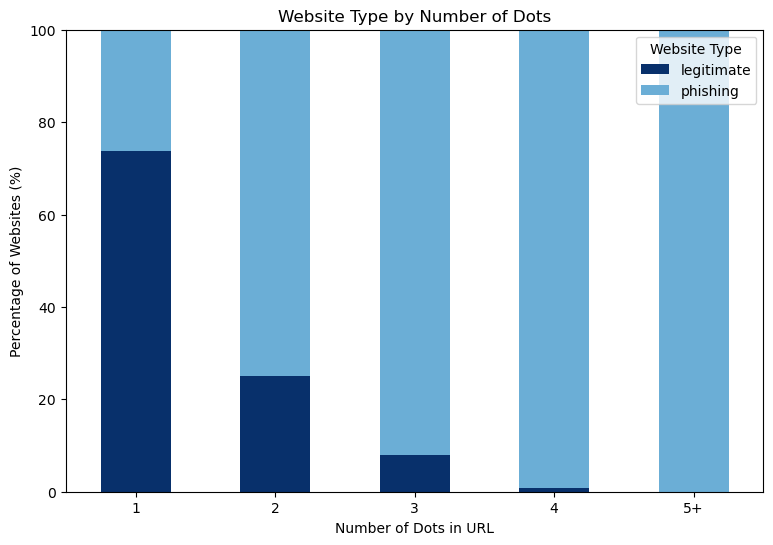

In [117]:
df_dots = df.copy()
df_dots['dots_group'] = df_dots['num_dots'].apply(lambda x: '5+' if x >= 5 else str(x))

counts = pd.crosstab(df_dots['dots_group'], df_dots['label'])
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
percentages = percentages.reindex(['1', '2', '3', '4', '5+'])

ax = percentages[['legitimate', 'phishing']].plot(
    kind='bar', stacked=True, figsize=(9, 6),
    color=['#08306b', '#6baed6']
)

plt.title('Website Type by Number of Dots')
plt.xlabel('Number of Dots in URL')
plt.ylabel('Percentage of Websites (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title='Website Type')
plt.show()

##### **Figure: Website Type by Number of Dots in URL**

URLs with more dots are far more likely to be phishing. Legitimate sites mostly have 1 dot (~74%), while phishing dominates at 2+ dots, reaching nearly 100% by 4–5 dots.

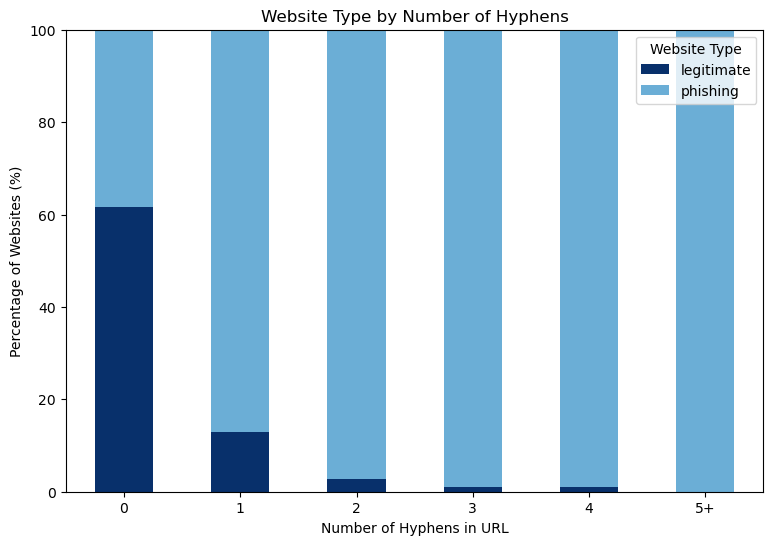

In [118]:
df_hyphens = df.copy()
df_hyphens['hyphens_group'] = df_hyphens['num_hyphens'].apply(lambda x: '5+' if x >= 5 else str(x))

counts = pd.crosstab(df_hyphens['hyphens_group'], df_hyphens['label'])
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
percentages = percentages.reindex([str(i) for i in range(5)] + ['5+'])

ax = percentages[['legitimate', 'phishing']].plot(
    kind='bar', stacked=True, figsize=(9, 6),
    color=['#08306b', '#6baed6']
)

plt.title('Website Type by Number of Hyphens')
plt.xlabel('Number of Hyphens in URL')
plt.ylabel('Percentage of Websites (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title='Website Type')
plt.show()

##### Figure: Website Type by Number of Hyphens in URL

Hyphens are an even stronger phishing signal than dots. URLs with no hyphens are majority legitimate (~62%), but even a single hyphen flips this to ~87% phishing, and 2+ hyphens is almost entirely phishing.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5464\89129480.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




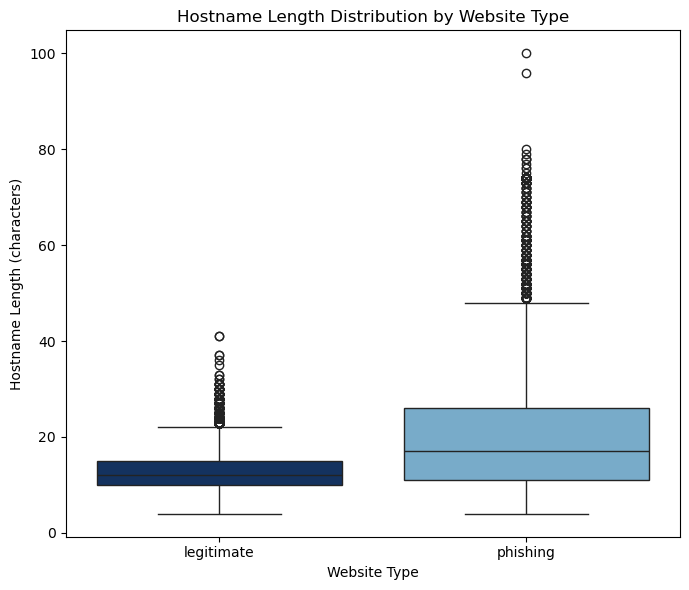

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    "legitimate": "#08306b",   
    "phishing": "#6baed6"      
}

plt.figure(figsize=(7,6))
sns.boxplot(data=df, x='label', y='length_hostname', palette=palette)
plt.title('Hostname Length Distribution by Website Type')
plt.xlabel('Website Type')
plt.ylabel('Hostname Length (characters)')
plt.tight_layout()
plt.show()

##### Figure: Hostname Length Distribution by Website Type
Phishing hostnames tend to be longer and much more variable than legitimate ones. Legitimate hostnames cluster tightly around 10–15 characters, while phishing hostnames have a higher median (~17) and a wide spread reaching up to 80+ characters. This is consistent with attackers using long, deceptive subdomains to disguise malicious URLs as trusted brands. Based on 60,000 labeled URLs.

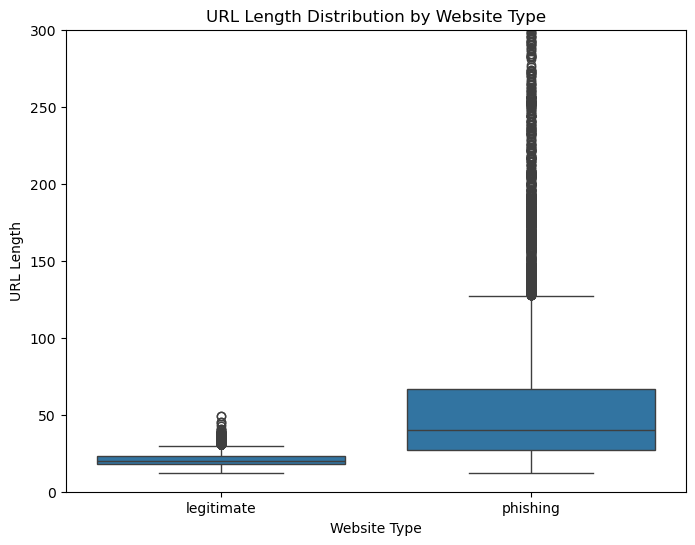

In [120]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='label', y='url_length')
plt.ylim(0, 300)  # cap the view, outliers beyond this still get flagged, just not shown
plt.title('URL Length Distribution by Website Type')
plt.xlabel('Website Type')
plt.ylabel('URL Length')
plt.show()

##### Figure: URL Length Distribution by Website Type

Phishing URLs are longer and much more variable in length than legitimate ones. Legitimate URLs cluster tightly around 20 characters, while phishing URLs have a higher median (~40) and a wide spread up to 300+ characters.

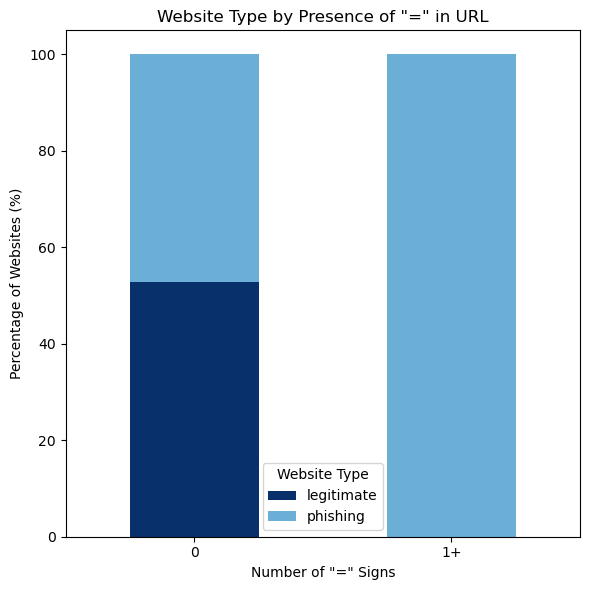

In [90]:
import pandas as pd
import matplotlib.pyplot as plt

# Binary bucket: 0 vs 1+
df['eq_binary'] = df['num_eq'].apply(lambda x: '0' if x == 0 else '1+')

ct = pd.crosstab(df['eq_binary'], df['label'], normalize='index') * 100
ct = ct.reindex(['0', '1+'])

ct.plot(kind='bar', stacked=True, figsize=(6,6), color=['#08306b', '#6baed6'])

plt.title('Website Type by Presence of "=" in URL')
plt.xlabel('Number of "=" Signs')
plt.ylabel('Percentage of Websites (%)')
plt.xticks(rotation=0)
plt.legend(title='Website Type')
plt.tight_layout()
plt.show()

##### Figure: Website Type by Presence of "=" in URL

The presence of an "=" sign in a URL is a near-perfect phishing indicator. URLs with no "=" are split roughly evenly (~53% legitimate / 47% phishing), while virtually all URLs containing one or more "=" signs are phishing.

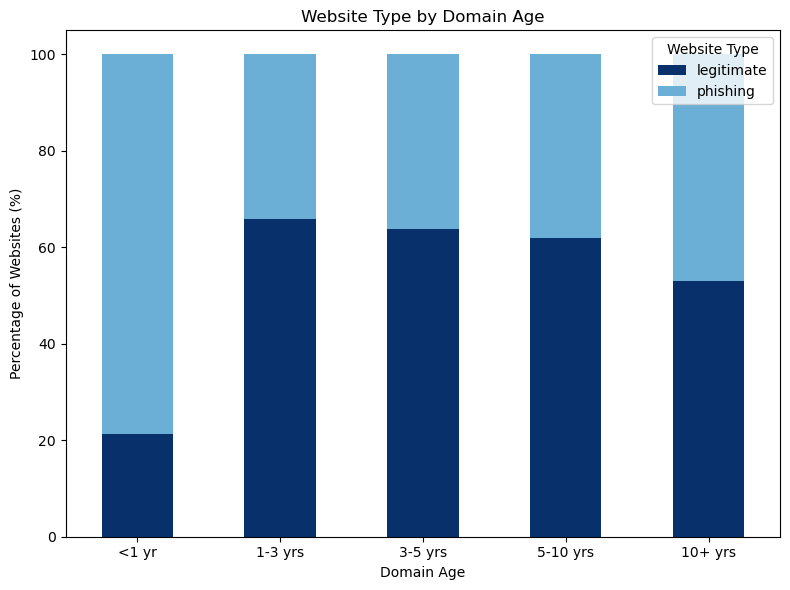

In [89]:
import pandas as pd
import matplotlib.pyplot as plt

bucket_order = ['<1 yr', '1-3 yrs', '3-5 yrs', '5-10 yrs', '10+ yrs']

ct = pd.crosstab(known['age_bucket'], known['label'], normalize='index') * 100
ct = ct.reindex(bucket_order)

ct.plot(kind='bar', stacked=True, figsize=(8,6), color=['#08306b', '#6baed6'])

plt.title('Website Type by Domain Age')
plt.xlabel('Domain Age')
plt.ylabel('Percentage of Websites (%)')
plt.xticks(rotation=0)
plt.legend(title='Website Type')
plt.tight_layout()
plt.show()

##### Figure: Website Type by Domain Age

Domain age shows a mixed relationship with website type. Newly registered domains (under 1 year) are overwhelmingly phishing (~79%), the clearest red flag in the data. However, legitimacy doesn't continue to rise with age — the 1–3 year bucket has the highest legitimate share (~66%), while very old domains (10+ years) drop back down to a near-even split (~53% legitimate). Based on 41,323 domains with known registration age (31% of the dataset had unresolvable WHOIS data, which is itself associated with a higher phishing rate).

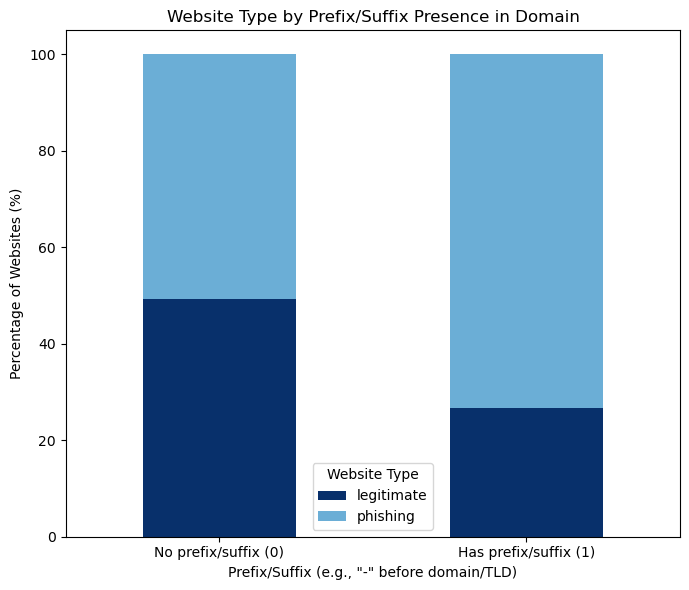

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

ct = pd.crosstab(df['prefix_suffix'], df['label'], normalize='index') * 100
ct.index = ['No prefix/suffix (0)', 'Has prefix/suffix (1)']

ct.plot(kind='bar', stacked=True, figsize=(7,6), color=['#08306b', '#6baed6'])

plt.title('Website Type by Prefix/Suffix Presence in Domain')
plt.xlabel('Prefix/Suffix (e.g., "-" before domain/TLD)')
plt.ylabel('Percentage of Websites (%)')
plt.xticks(rotation=0)
plt.legend(title='Website Type')
plt.tight_layout()
plt.show()

##### Figure: Website Type by Prefix/Suffix Presence in Domain

Domains with a prefix/suffix hyphen (e.g., "paypal-secure.com") are notably more likely to be phishing — about 73%, compared to ~51% for domains without one. The signal is real but moderate, weaker than features like number of hyphens or equal signs. Based on 60,000 labeled URLs

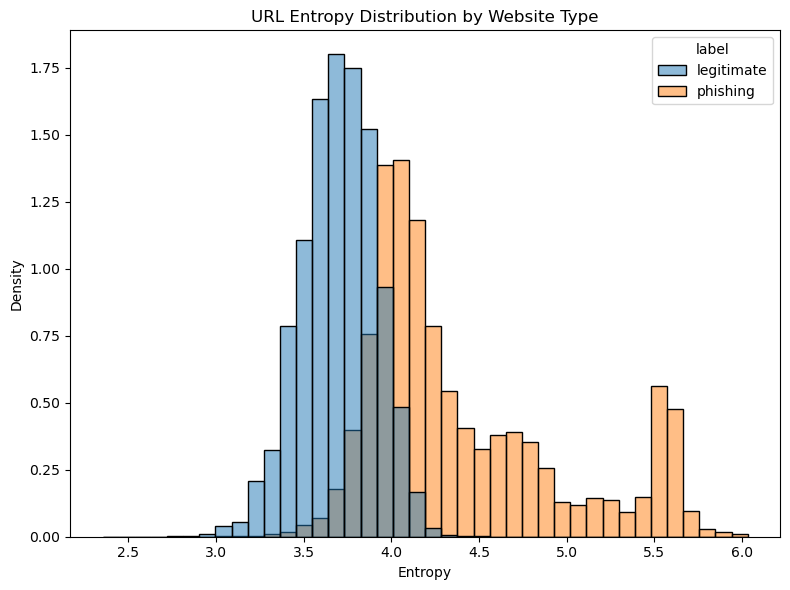

In [122]:

plt.figure(figsize=(8,6))
sns.histplot(data=df, x='entropy', hue='label', bins=40, stat='density', common_norm=False, alpha=0.5)
plt.title('URL Entropy Distribution by Website Type')
plt.xlabel('Entropy')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

##### Figure: URL Entropy Distribution by Website Type
Phishing URLs show higher and more variable entropy (randomness) than legitimate ones. Legitimate URLs cluster tightly around 3.5–3.8, while phishing URLs are shifted higher with a long tail extending past 5.0 — suggesting greater use of randomized or obfuscated text. Based on 60,000 labeled URLs.

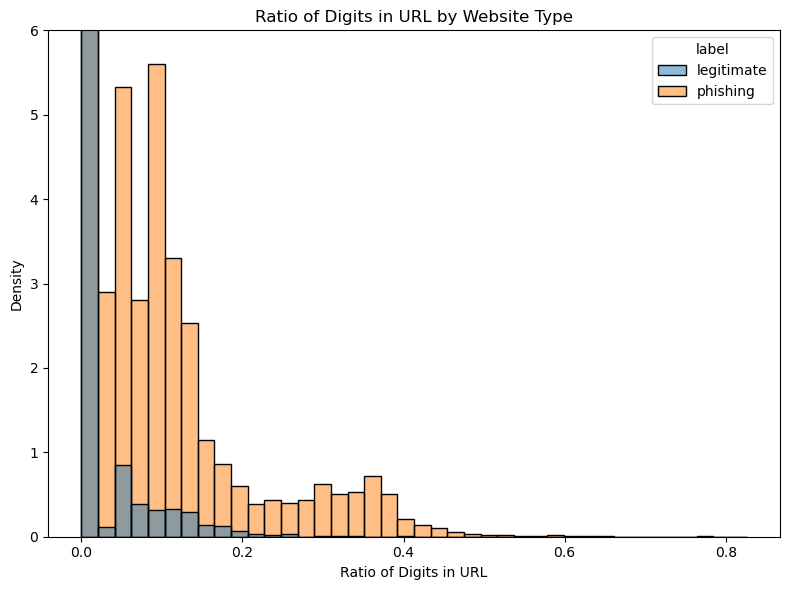

In [49]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='ratio_digits_url', hue='label', bins=40, stat='density', common_norm=False, alpha=0.5)
plt.ylim(0, 6)  # cut off the spike so we can see the rest
plt.title('Ratio of Digits in URL by Website Type')
plt.xlabel('Ratio of Digits in URL')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

##### **Figure: Website Type by Presence of Digits in URL**

Legitimate URLs almost never contain digits (~70% have none), while URLs that do contain digits are overwhelmingly phishing (~93%). Digit presence is a strong, easily interpretable phishing signal. Based on 60,000 labeled URLs.


x = 0.0 means "this URL has no digits at all" (that's the huge spike — most legitimate URLs land exactly here)

x = 0.2 means "20% of this URL's characters are digits"

x = 0.6–0.8 (far right, rare) means the URL is mostly digits — a heavily numeric/suspicious-looking URL

The y-axis (density) then tells you how common each of those ratios is, separately for legitimate vs phishing URLs — which is why you see the huge legitimate spike exactly at 0, while phishing URLs spread out across many nonzero ratios.

In [63]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calculate percentages
ct = pd.crosstab(df['dns_resolvable'], df['label'], normalize='index') * 100

fig = make_subplots(rows=1, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}]],
                     subplot_titles=['Not Resolvable (0)', 'Resolvable (1)'])

fig.add_trace(go.Pie(labels=ct.columns, values=ct.loc[0.0], hole=0.5,
                      marker=dict(colors=['#08306b', '#6baed6'])), 1, 1)
fig.add_trace(go.Pie(labels=ct.columns, values=ct.loc[1.0], hole=0.5,
                      marker=dict(colors=['#08306b', '#6baed6'])), 1, 2)

fig.update_layout(title_text='Website Type by DNS Resolvability', showlegend=True)
fig.show()

##### Figure: Website Type by DNS Resolvability

Domains that cannot be resolved through DNS are almost always phishing (95.7%), while resolvable domains split close to evenly (50.5% legitimate). DNS resolvability is one of the strongest indicators in the dataset. Based on 60,000 labeled URLs

In [67]:
import plotly.express as px

palette = {
    "legitimate": "#08306b",   # dark blue
    "phishing": "#6baed6"      # light blue
}

bucket_order = ['0', '1-2', '3-4', '5+']

# Build a long-format dataframe: bucket, label, percentage
ct2 = pd.crosstab(df['ns_bucket'], df['label'], normalize='index') * 100
ct2 = ct2.reindex(bucket_order)

treemap_df = ct2.reset_index().melt(id_vars='ns_bucket', 
                                      value_vars=['legitimate', 'phishing'],
                                      var_name='label', value_name='percentage')

fig = px.treemap(
    treemap_df,
    path=['ns_bucket', 'label'],
    values='percentage',
    color='label',
    color_discrete_map=palette,
    title='Website Type by Number of Name Servers'
)

fig.update_traces(textinfo='label+percent parent')
fig.show()

##### Figure: Website Type by Number of Name Servers

Domains with zero name servers are overwhelmingly phishing (94%), the strongest signal in this feature. Beyond that, the relationship isn't linear — the 1–2 bucket has the highest legitimate share (65%), while 3–4 (41% legitimate) and 5+ (48% legitimate) show more mixed results. Based on 60,000 labeled URLs.

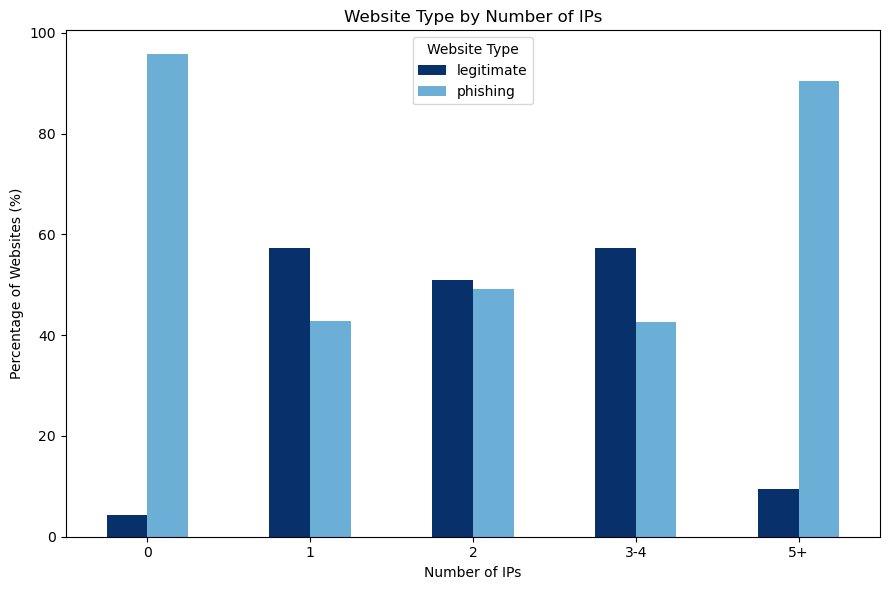

In [84]:
import matplotlib.pyplot as plt
import pandas as pd

palette = {
    "legitimate": "#08306b",
    "phishing": "#6baed6"
}

bucket_order = ['0', '1', '2', '3-4', '5+']

ct = pd.crosstab(df['ip_bucket'], df['label'], normalize='index') * 100
ct = ct[['legitimate', 'phishing']]
ct = ct.reindex(bucket_order)

ct.plot(kind='bar', stacked=False, figsize=(9,6), 
         color=[palette['legitimate'], palette['phishing']])
plt.title('Website Type by Number of IPs')
plt.xlabel('Number of IPs')
plt.ylabel('Percentage of Websites (%)')
plt.xticks(rotation=0)
plt.legend(title='Website Type')
plt.tight_layout()
plt.show()

##### Figure: Website Type by Number of IPs

Websites with no resolvable IPs are almost always phishing (~96%), consistent with failed DNS lookups. Having 1–4 IPs is associated with a more balanced mix (51–57% legitimate), but websites with 5 or more IPs shift sharply back toward phishing (~90%) — a pattern consistent with "fast-flux" techniques where attackers rotate IP addresses to evade detection. Based on 60,000 labeled URLs.

In [95]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

palette = {
    "legitimate": "#08306b",   # dark blue
    "phishing": "#6baed6"      # light blue
}

ct = pd.crosstab(df['www_bucket'], df['label'], normalize='index') * 100
ct = ct.reindex(['0', '1+'])

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'domain'}, {'type':'domain'}]],
    subplot_titles=['No "www" (0)', 'Has "www" (1+)']
)

fig.add_trace(go.Pie(labels=['legitimate','phishing'], 
                      values=[ct.loc['0','legitimate'], ct.loc['0','phishing']],
                      hole=0.5,
                      marker=dict(colors=[palette['legitimate'], palette['phishing']])), 1, 1)

fig.add_trace(go.Pie(labels=['legitimate','phishing'], 
                      values=[ct.loc['1+','legitimate'], ct.loc['1+','phishing']],
                      hole=0.5,
                      marker=dict(colors=[palette['legitimate'], palette['phishing']])), 1, 2)

fig.update_layout(title_text='Website Type by Presence of "www" in URL', showlegend=True)
fig.show()

##### Figure: Website Type by Presence of "www" in URL 
URLs containing "www" are more likely to be legitimate (~78%), while URLs without it lean toward phishing (~56%). This aligns with "www" being a conventional prefix more common among established, legitimate domains. Based on 60,000 labeled URLs.

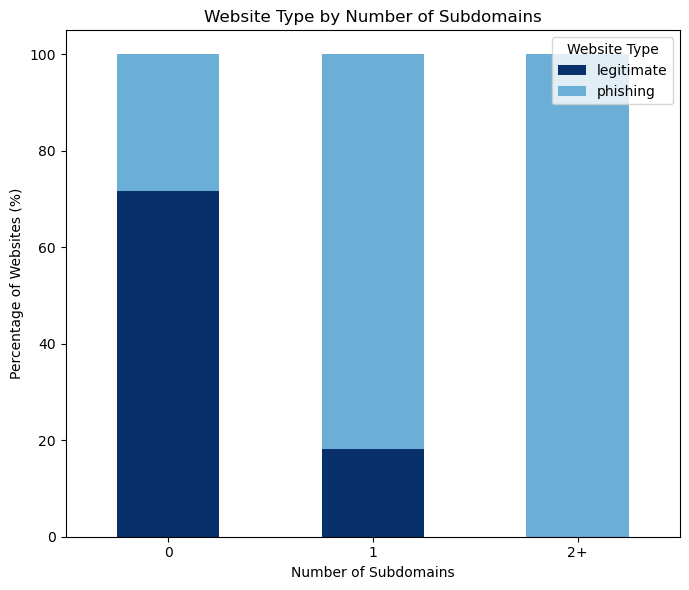

In [102]:
palette = {
    "legitimate": "#08306b",   # dark blue
    "phishing": "#6baed6"      # light blue
}

def subdomain_bucket(n):
    if n == 0:
        return '0'
    elif n == 1:
        return '1'
    else:
        return '2+'

df['subdomain_bucket'] = df['num_subdomains'].apply(subdomain_bucket)
bucket_order = ['0', '1', '2+']

ct = pd.crosstab(df['subdomain_bucket'], df['label'], normalize='index') * 100
ct = ct[['legitimate', 'phishing']]
ct = ct.reindex(bucket_order)

ct.plot(kind='bar', stacked=True, figsize=(7,6), 
         color=[palette['legitimate'], palette['phishing']])
plt.title('Website Type by Number of Subdomains')
plt.xlabel('Number of Subdomains')
plt.ylabel('Percentage of Websites (%)')
plt.xticks(rotation=0)
plt.legend(title='Website Type')
plt.tight_layout()
plt.show()

##### Figure: Website Type by Number of Subdomains

The presence of subdomains is a strong phishing signal. URLs with no subdomains are mostly legitimate (~72%), but adding even one subdomain flips this sharply to ~82% phishing, and 2 or more subdomains is almost entirely phishing. Based on 60,000 labeled URLs.

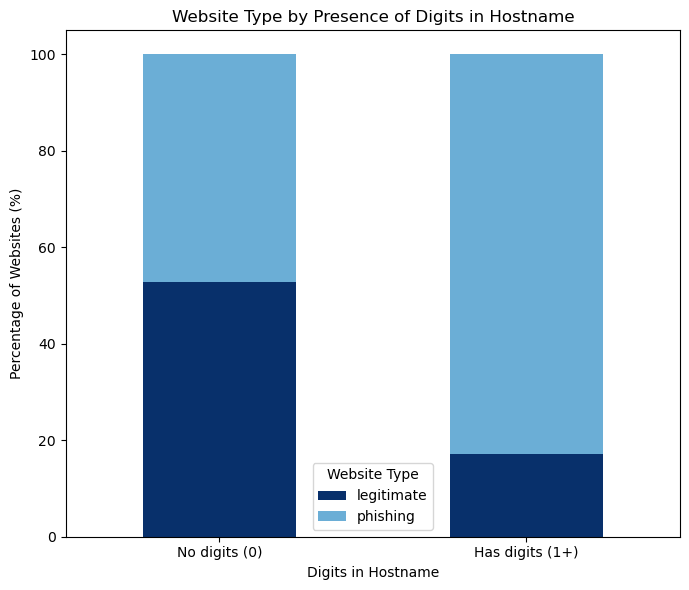

In [105]:
palette = {
    "legitimate": "#08306b",   # dark blue
    "phishing": "#6baed6"      # light blue
}

ct = pd.crosstab(df['host_has_digits'], df['label'], normalize='index') * 100
ct = ct[['legitimate', 'phishing']]
ct = ct.reindex(['No digits (0)', 'Has digits (1+)'])

ct.plot(kind='bar', stacked=True, figsize=(7,6), 
         color=[palette['legitimate'], palette['phishing']])
plt.title('Website Type by Presence of Digits in Hostname')
plt.xlabel('Digits in Hostname')
plt.ylabel('Percentage of Websites (%)')
plt.xticks(rotation=0)
plt.legend(title='Website Type')
plt.tight_layout()
plt.show()

##### Figure: Website Type by Presence of Digits in Hostname

Digits in the hostname itself are a strong phishing indicator. URLs with no digits in the hostname are close to an even split (~53% legitimate), but URLs with digits in the hostname are overwhelmingly phishing (~83%). This is a more specific signal than digits anywhere in the URL, since it targets the domain name itself.

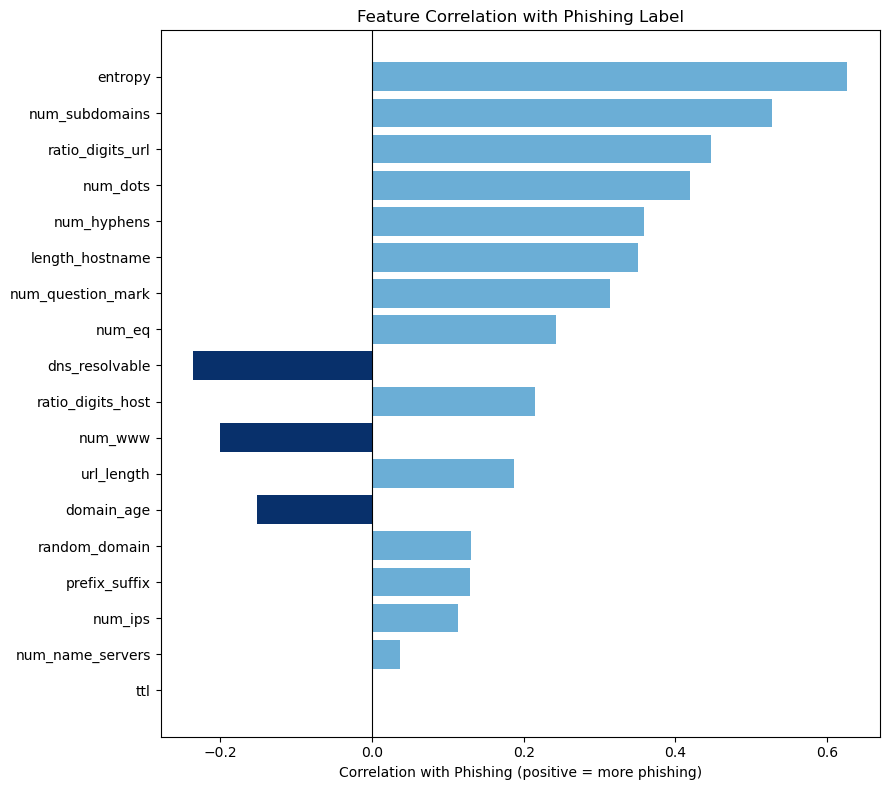

In [109]:
import matplotlib.pyplot as plt

label_corr_clean = label_corr.drop('label_binary')
sorted_corr = label_corr_clean.reindex(label_corr_clean.abs().sort_values(ascending=True).index)

colors = ['#6baed6' if x > 0 else '#08306b' for x in sorted_corr]

plt.figure(figsize=(9,8))
plt.barh(sorted_corr.index, sorted_corr.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Phishing Label')
plt.xlabel('Correlation with Phishing (positive = more phishing)')
plt.tight_layout()
plt.show()

##### Figure: Feature Correlation with Phishing Label

This chart ranks how strongly each feature correlates with a website being phishing (positive bars) versus legitimate (negative bars). Entropy is the single strongest individual predictor (0.63), followed by num_subdomains (0.53) and ratio_digits_url (0.45). A handful of features — dns_resolvable, num_www, and domain_age — show negative correlations, meaning higher values are associated with legitimate sites instead. ttl and num_name_servers show almost no relationship with the label on their own.

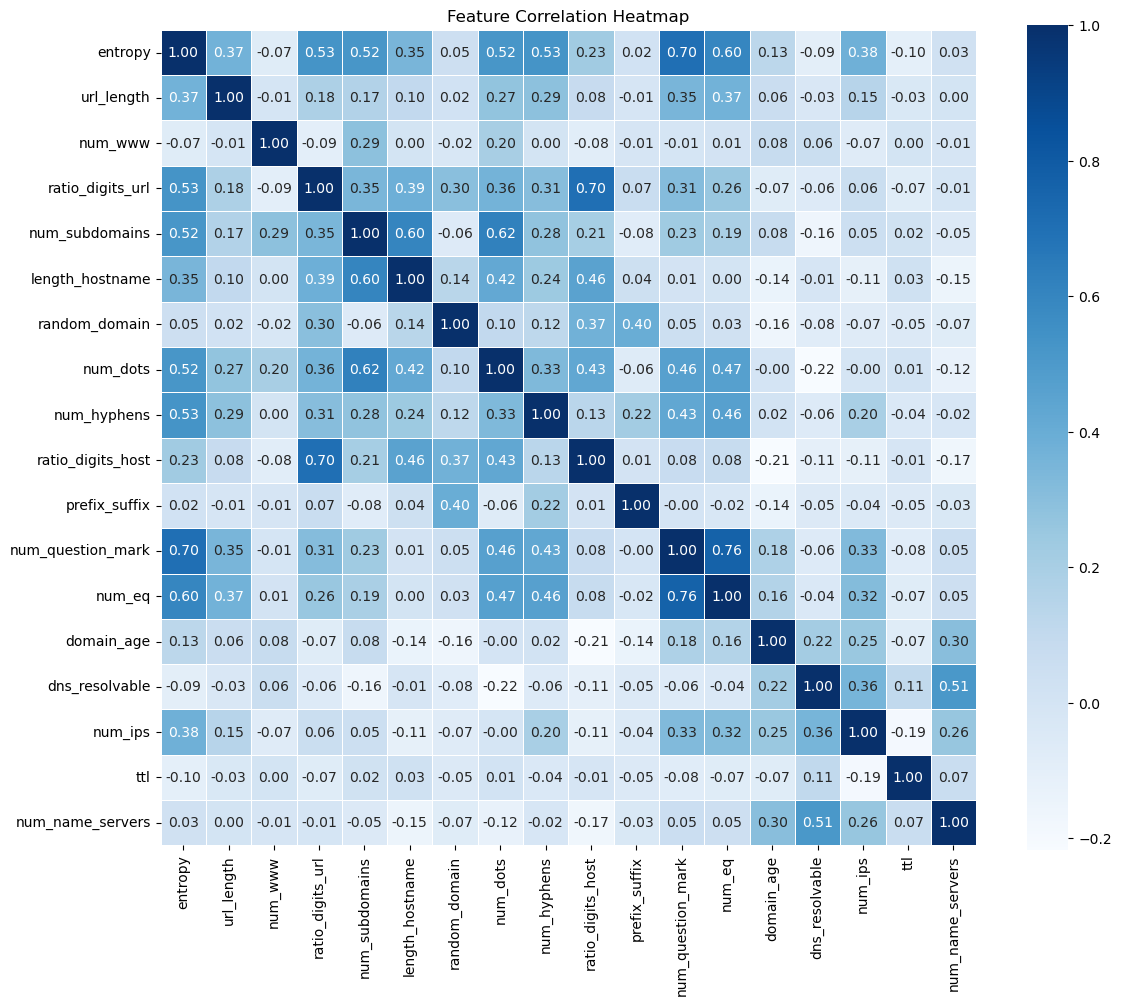

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='Blues', 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Figure: Feature Correlation Heatmap

This heatmap shows the pairwise correlation between all numeric features in the dataset. Most features are weakly to moderately correlated, confirming that the individual charts in this analysis largely capture distinct signals rather than duplicating one another. The strongest relationships are between num_question_mark and num_eq (0.76), and between ratio_digits_url and ratio_digits_host (0.70) — both pairs of closely related URL-structure features.
